This routine tests the Gramian and extended Gramian closure for even and odd $M$ for hyperbolicity.

It also shows the missing hyperbolicity of the old extended Gramian closure for odd $M$.

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.integrate import quad
from tqdm import tqdm

sp.init_printing(use_unicode=True)

In [ ]:
def get_jacobian_factory_NewVersion(M_val):
    """Symbolic derivation of the Jacobian based on the gradient of the closure."""
    n = (M_val + 1) // 2
    u = sp.symbols(f'u:{(2*n)}')
    
    def get_sigma_kk(k):
        if k == 0: return u[0]
        G_km1 = sp.Matrix(k, k, lambda i, j: u[i + j])
        u_vec = sp.Matrix([u[k + i] for i in range(k)])
        return u[2*k] - (u_vec.T * G_km1.inv() * u_vec)[0]

    def get_sigma_k_kp1(k):
        if k == 0: return u[1]
        G_km1 = sp.Matrix(k, k, lambda i, j: u[i + j])
        u_vec_front = sp.Matrix([u[k + 1 + i] for i in range(k)])
        u_vec_back = sp.Matrix([u[k + i] for i in range(k)])
        return u[2*k + 1] - (u_vec_front.T * G_km1.inv() * u_vec_back)[0]

    sigmas_diag = [get_sigma_kk(k) for k in range(n)]
    sigmas_off  = [get_sigma_k_kp1(k) for k in range(n)]
    alphas = []
    for k in range(n):
        term_k = sigmas_off[k] / sigmas_diag[k]
        term_km1 = sigmas_off[k-1] / sigmas_diag[k-1] if k > 0 else 0
        alphas.append(sp.simplify(term_k - term_km1))
    betas = [sigmas_diag[k] / sigmas_diag[k-1] for k in range(1, n)]

    G_nm1 = sp.Matrix(n, n, lambda i, j: u[i + j])
    u_vec_n = sp.Matrix([u[n + i] for i in range(n)])
    term_A = (u_vec_n.T * G_nm1.inv() * u_vec_n)[0]
    bracket = (2/(n-1)) * sum(betas) + (1/(n-1)) * sum((alphas[n-1] - alphas[l])**2 for l in range(n))
    u2n_closure = term_A + sigmas_diag[n-1] * bracket

    grads = [sp.diff(u2n_closure, ux) for ux in u]
    DF = sp.Matrix(M_val + 1, M_val + 1, lambda i, j: 0)
    for i in range(M_val): DF[i, i+1] = 1
    for j in range(M_val + 1): DF[M_val, j] = grads[j]

    return sp.lambdify(u, DF, modules='numpy'), n

In [ ]:
def get_jacobian_factory_GramOdd(M_val, version="ExtendedGramian"):
    """
    Implements the odd (Extended) Gramian closure model based on the formula:
    u_{2n} = u_{n+1,2n-1}^T * G_{n-2}^-1 * u_{n-1,2n-3} + 
             chi * (u_{2n-1} - u_{n,2n-2}^T * G_{n-2}^-1 * u_{n-1,2n-3})^2 / 
                   (u_{2n-2} - u_{n-1,2n-3}^T * G_{n-2}^-1 * u_{n-1,2n-3})
    """
    n = (M_val + 1) // 2
    u = sp.symbols(f'u:{(2*n)}')
    chi = (n+1)/(2*n)

    if version=="ExtendedGramian":
        G_nm2 = sp.Matrix(n-1, n-1, lambda i, j: u[i + j])
        G_nm2_inv = G_nm2.inv()

        # Define the shifted moment vectors required by the formula
        # u_{n-1, 2n-3}
        u_vec_A = sp.Matrix([u[n - 1 + i] for i in range(n - 1)])
        
        # u_{n+1, 2n-1}
        u_vec_B = sp.Matrix([u[n + 1 + i] for i in range(n - 1)])
        
        # u_{n, 2n-2}
        u_vec_C = sp.Matrix([u[n + i] for i in range(n - 1)])

        # --- Construct the Closure u_{2n} ---
        # Term 1: u_{n+1, 2n-1}^T * G_{n-2}^-1 * u_{n-1, 2n-3}
        term1 = (u_vec_B.T * G_nm2_inv * u_vec_A)[0]

        # Term 2: Chi * (Numerator)^2 / Denominator
        # Numerator: u_{2n-1} - u_{n, 2n-2}^T * G_{n-2}^-1 * u_{n-1, 2n-3}
        numerator = u[2*n - 1] - (u_vec_C.T * G_nm2_inv * u_vec_A)[0]
        
        # Denominator: u_{2n-2} - u_{n-1, 2n-3}^T * G_{n-2}^-1 * u_{n-1, 2n-3}
        denominator = u[2*n - 2] - (u_vec_A.T * G_nm2_inv * u_vec_A)[0]
        
        u2n_closure = term1 + chi * (numerator**2) / denominator
    elif version=="Gramian":
            # Matrices and Vectors
            G_nm1 = sp.Matrix(n, n, lambda i, j: u[i + j])
            G_nm1_inv = G_nm1.inv()

            # Vectors for sigma terms
            u_n_2nm1 = sp.Matrix([u[n + i] for i in range(n)])

            # Equation components
            u2n_closure = (u_n_2nm1.T * G_nm1_inv * u_n_2nm1)[0]
    else:
        raise ValueError(f"Unknown version: {version}")("ExtendedGramian", "Gramian")

    # --- Jacobian Formation ---
    # Compute gradients with respect to u0, u1, ..., u_{2n-1}
    grads = [sp.diff(u2n_closure, ux) for ux in u]
    
    # Create the companion-style Jacobian matrix
    DF = sp.Matrix(M_val + 1, M_val + 1, lambda i, j: 0)
    for i in range(M_val): DF[i, i+1] = 1
    for j in range(M_val + 1): DF[M_val, j] = grads[j]

    return sp.lambdify(u, DF, modules='numpy'), n

In [ ]:
def get_jacobian_factory_GramEven(M_val, version="ExtendedGramian"):
    """
    (Extended) Gramian Closure, even M:
    u_{2n+1} = Term1 + chi * (sigma_nn / sigma_{n-1,n-1}) * sigma_{n-1,n}
    """
    n = M_val // 2
    u = sp.symbols(f'u:{(M_val + 1)}')
    chi = (n + 1) / n

    def get_G(k):
        if k < 0: return sp.Matrix([1])
        return sp.Matrix(k + 1, k + 1, lambda i, j: u[i + j])

    # Matrices and Vectors
    G_nm1_inv = get_G(n - 1).inv()
    G_nm2_inv = get_G(n - 2).inv()
    
    # Vectors for sigma terms
    u_n_2nm1 = sp.Matrix([u[n + i] for i in range(n)])
    u_np1_2n = sp.Matrix([u[n + 1 + i] for i in range(n)])
    u_nm1_2nm3 = sp.Matrix([u[n - 1 + i] for i in range(n - 1)])
    u_n_2nm2 = sp.Matrix([u[n + i] for i in range(n - 1)])

    # Equation components
    term1_offset = (u_np1_2n.T * G_nm1_inv * u_n_2nm1)[0]
    
    if version == "ExtendedGramian":
        sigma_nn = u[2*n] - (u_n_2nm1.T * G_nm1_inv * u_n_2nm1)[0]
        sigma_nm1_nm1 = u[2*n - 2] - (u_nm1_2nm3.T * G_nm2_inv * u_nm1_2nm3)[0]
        sigma_nm1_n = u[2*n - 1] - (u_n_2nm2.T * G_nm2_inv * u_nm1_2nm3)[0]

        # Assembly of closure u_{M+1} (u_{2n+1})
        u_M_plus_1 = term1_offset + chi * (sigma_nn / sigma_nm1_nm1) * sigma_nm1_n
    elif version == "Gramian":
        u_M_plus_1 = term1_offset
    else:
        raise ValueError("Unknown version specified for Jacobian factory.")

    # Compute Jacobian
    grads = [sp.diff(u_M_plus_1, ux) for ux in u]
    DF = sp.Matrix(M_val + 1, M_val + 1, lambda i, j: 0)
    for i in range(M_val): DF[i, i+1] = 1
    for j in range(M_val + 1): DF[M_val, j] = grads[j]

    return sp.lambdify(u, DF, modules='numpy'), n

In [ ]:
def perform_analysis(M_list, sweep_range, sweep_label, moment_gen_func, title_suffix="", closure="NewVersion"):
    """Unified function to analyze and plot hyperbolicity for any distribution."""
    fig, axes = plt.subplots(len(M_list), 1, figsize=(12, 5 * len(M_list)), sharex=True)
    if len(M_list) == 1: axes = [axes]

    for idx, M in enumerate(M_list):
        if closure == "NewVersion" and M % 2 != 0: # odd
            jac_func, n_val = get_jacobian_factory_NewVersion(M)
        elif M % 2 == 0: # even
            jac_func, n_val = get_jacobian_factory_GramEven(M, version=closure)
        elif M % 2 != 0: # odd
            jac_func, n_val = get_jacobian_factory_GramOdd(M, version=closure)
        else:
            raise ValueError("Unknown closure type specified.")
        results = {'val': [], 'max_im': [], 'status': []} 

        # Status codes: 
        # 0 = Realizable + Strongly Hyperbolic (distinct real roots)
        # 1 = Realizable + Weakly Hyperbolic (repeated real roots)
        # 2 = Non-Realizable (Hankel matrix not positive definite)
        # 3 = Hyperbolicity lost (complex roots)
        for v in tqdm(sweep_range, desc=f"Scanning {sweep_label} (M={M})"):
            # try:
            # m_list = moment_gen_func(v, n_val)
            full_moments = moment_gen_func(v, M + 1) 
            m_list = full_moments[:M + 1]
            G_mat = np.array(sp.Matrix(n_val, n_val, lambda i, j: m_list[i+j]).tolist(), dtype=float)
            h_eigvals = np.linalg.eigvalsh(G_mat)
            
            if np.any(h_eigvals < 1e-11):
                results['status'].append(2) # Non-realizable
                results['max_im'].append(np.nan)
            else:
                # Hyperbolicity Analysis
                jac_num = jac_func(*m_list)
                evs = np.linalg.eigvals(jac_num)
                max_im = np.max(np.abs(np.imag(evs)))
                results['max_im'].append(max_im)
                
                if max_im > 1e-7: 
                    # Hyperbolicity lost
                    results['status'].append(3) 
                else:
                    # Check for distinctness (Weak vs Strong)
                    real_evs = np.sort(np.real(evs))
                    min_diff = np.min(np.diff(real_evs))
                    results['status'].append(1 if min_diff < 1e-5 else 0)
            # except:
            #     results['status'].append(2)
            #     results['max_im'].append(np.nan)
            results['val'].append(v)

        v_arr, s_arr, im_arr = np.array(results['val']), np.array(results['status']), np.array(results['max_im'])
        ax = axes[idx]
        ax.plot(v_arr, im_arr, color='gray', linestyle=':', alpha=0.5, label='Max |Im(λ)|')
        ax.scatter(v_arr[s_arr == 0], np.full(np.sum(s_arr == 0), 1e-12), color='forestgreen', label='Strongly Hyp.', s=15, alpha=0.7)
        ax.scatter(v_arr[s_arr == 1], np.full(np.sum(s_arr == 1), 1e-12), color='orange', label='Weakly Hyp.', s=20, edgecolors='black')
        ax.scatter(v_arr[s_arr == 3], im_arr[s_arr == 3], color='crimson', label='Hyp. Lost', s=25, marker='x')

        # Non-Realizable Region (Gray Shading)
        if np.any(s_arr == 2):
            for v_non in v_arr[s_arr == 2]:
                ax.axvspan(v_non - (sweep_range[1]-sweep_range[0])/2, v_non + (sweep_range[1]-sweep_range[0])/2, color='gray', alpha=0.1)
            ax.plot([], [], color='gray', alpha=0.3, label='Non-Realizable')

        ax.set_yscale('log')
        ax.set_ylim(1e-13, 1e1)
        ax.set_title(f'M={M} {title_suffix}', fontweight='bold')
        ax.set_ylabel('Max $|Im(\lambda)|$')
        ax.grid(True, which='both', linestyle='--', alpha=0.3)
        ax.legend(loc='upper right', fontsize='small', ncol=2)

    axes[-1].set_xlabel(sweep_label)
    plt.tight_layout()
    plt.show()

In [ ]:
# Distribution functions
# 1. Bimodal / Mott-Smith Physics
def get_bimodal_moments(n_val, rho1, v1, th1, rho2, v2, th2):
    def f(c):
        return (rho1/np.sqrt(2*np.pi*th1)) * np.exp(-(c-v1)**2/(2*th1)) + \
               (rho2/np.sqrt(2*np.pi*th2)) * np.exp(-(c-v2)**2/(2*th2))
    return [quad(lambda c: (c**k)*f(c), -np.inf, np.inf)[0] for k in range(2*n_val)]

# 2. Electron-Hole Physics
def get_eh_moments(n_val, phi, v0, beta):
    def f_eh(v):
        constant = (2 * np.pi)**(-0.5)
        v2 = v**2
        threshold = 2 * phi
        if v2 > threshold:
            exponent = -0.5 * (np.sign(v) * np.sqrt(v2 - threshold) - v0)**2
            return constant * np.exp(exponent)
        else:
            exponent = -0.5 * (beta * (v2 - threshold) + v0**2)
            return constant * np.exp(exponent)
    return [quad(lambda v: (v**k)*f_eh(v), -np.inf, np.inf)[0] for k in range(2*n_val)]

# Analysis of Hyperbolicity

## Gramian and Extended Gramian from the Paper

Scanning $v_2$ (M=5): 100%|██████████| 100/100 [00:03<00:00, 26.09it/s]


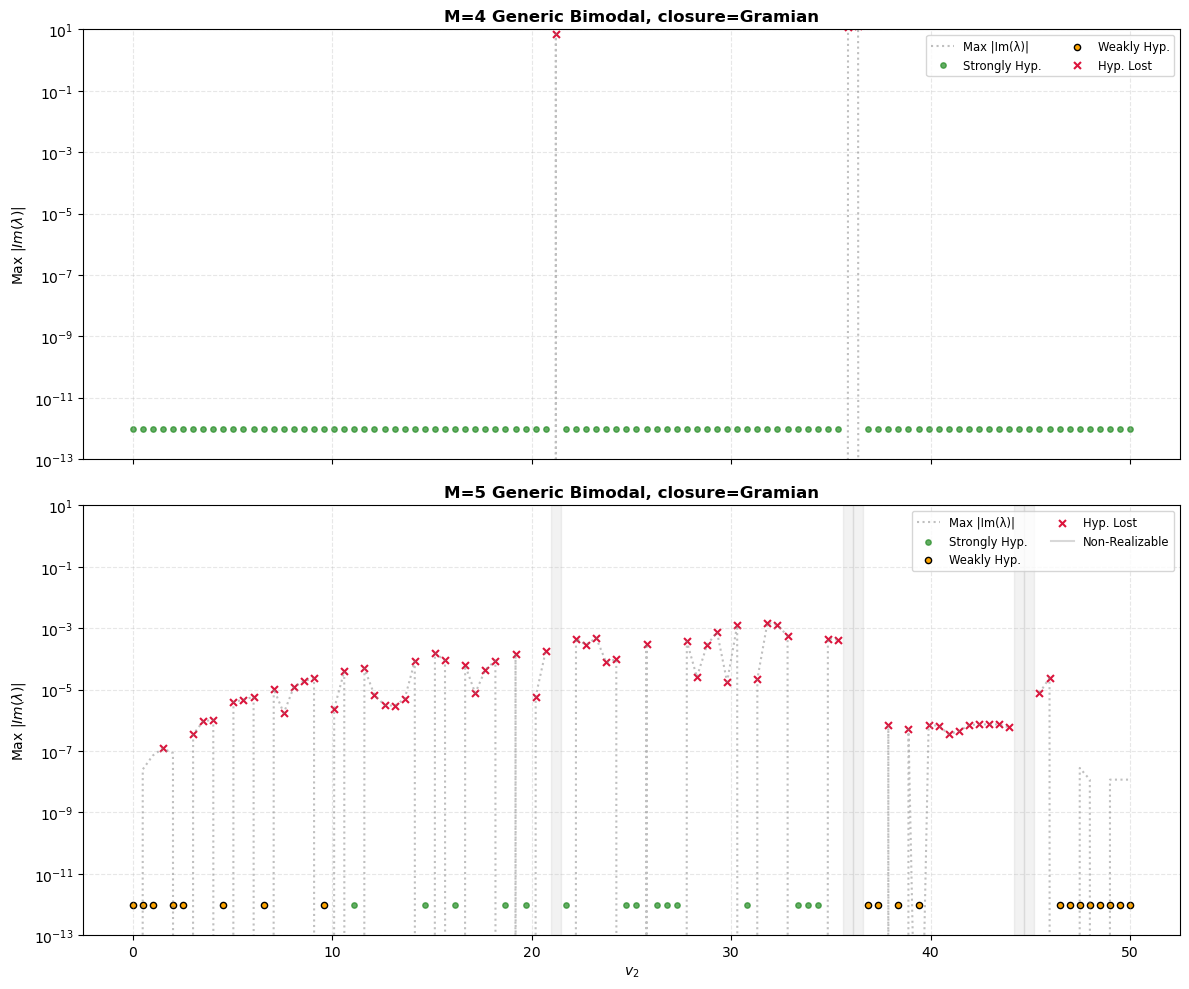

Scanning $x$ (M=5): 100%|██████████| 100/100 [00:03<00:00, 31.50it/s]


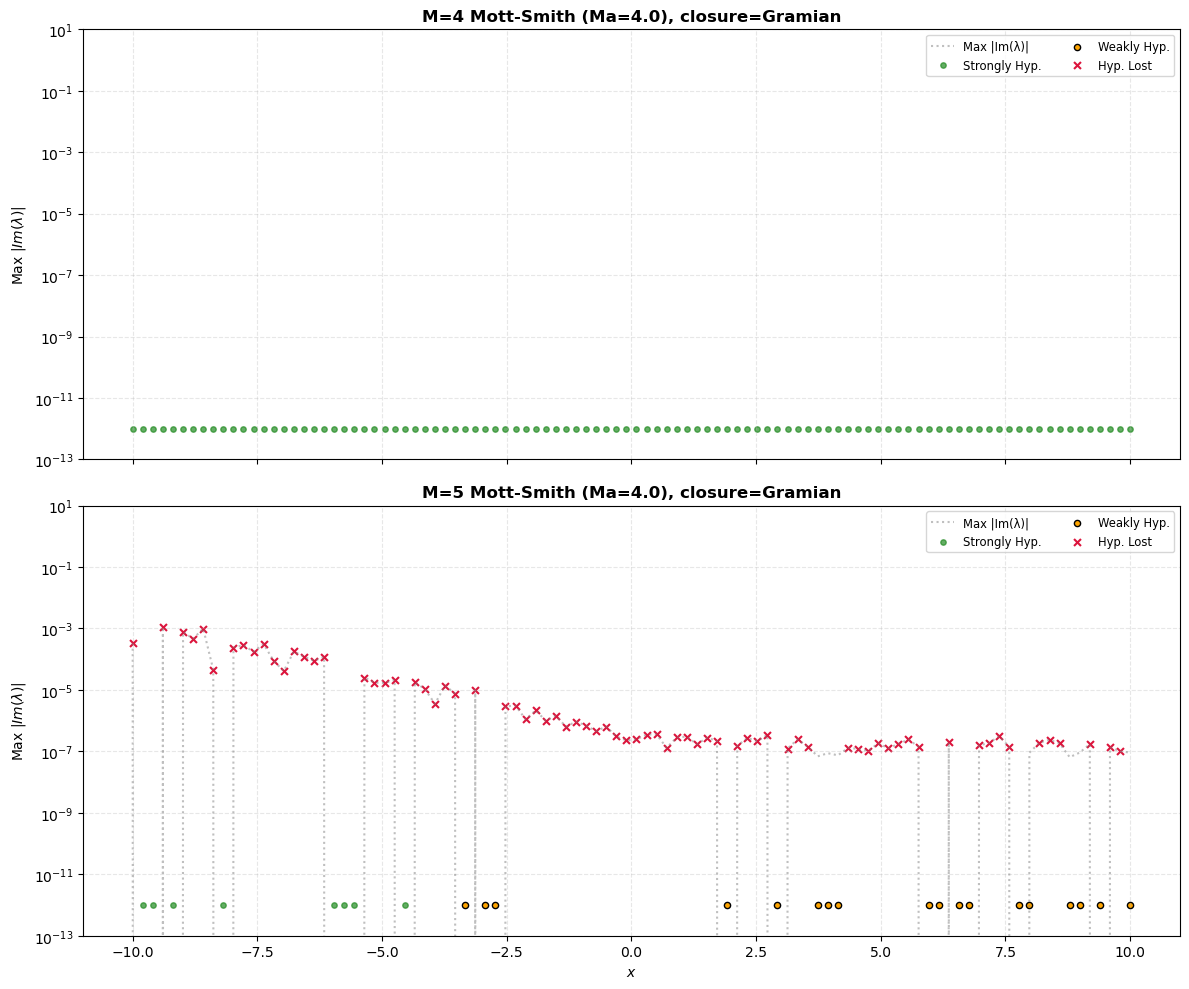

Scanning $\phi$ (M=5): 100%|██████████| 100/100 [00:03<00:00, 29.90it/s]


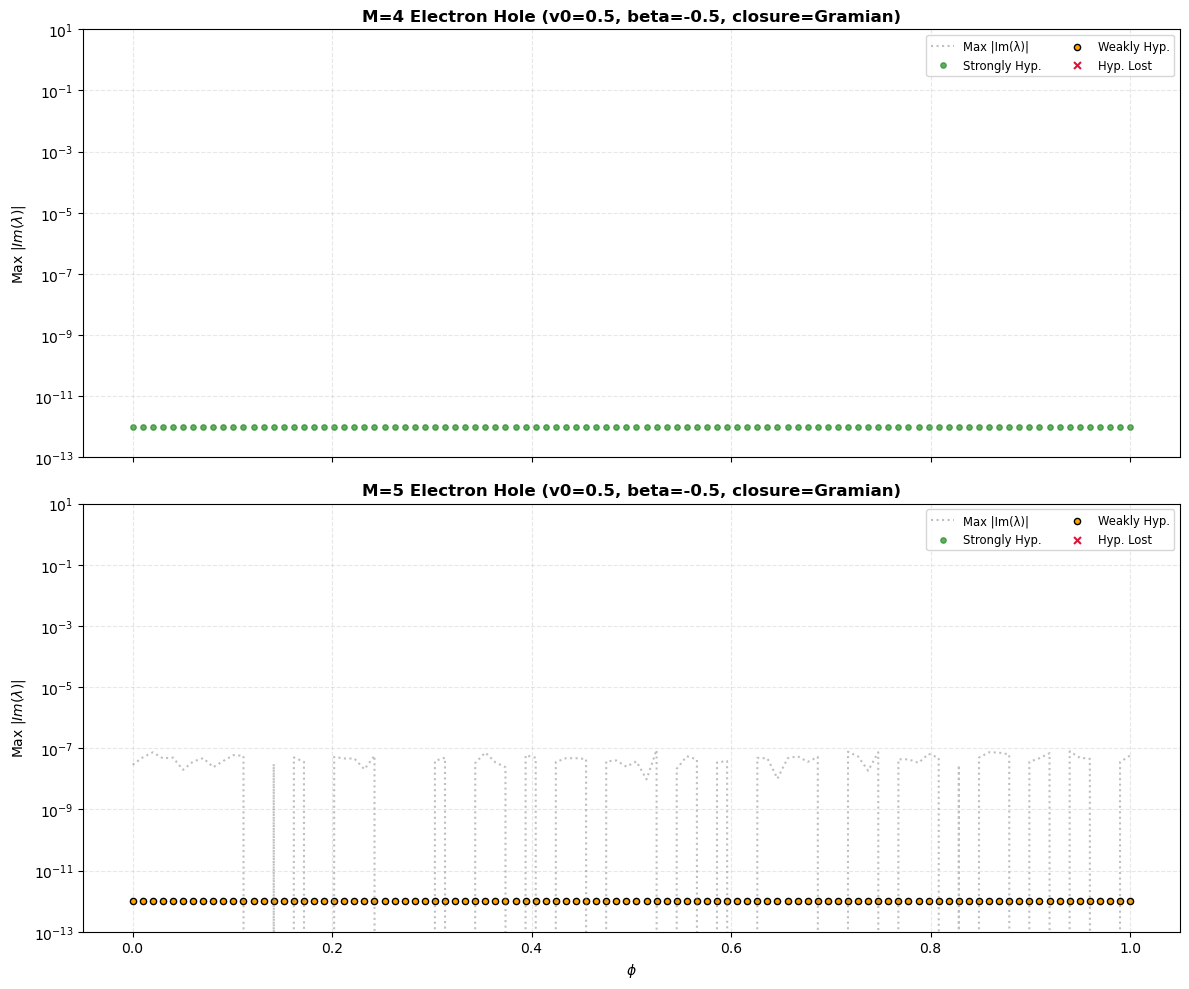

Scanning $v_2$ (M=5): 100%|██████████| 100/100 [00:03<00:00, 25.91it/s]


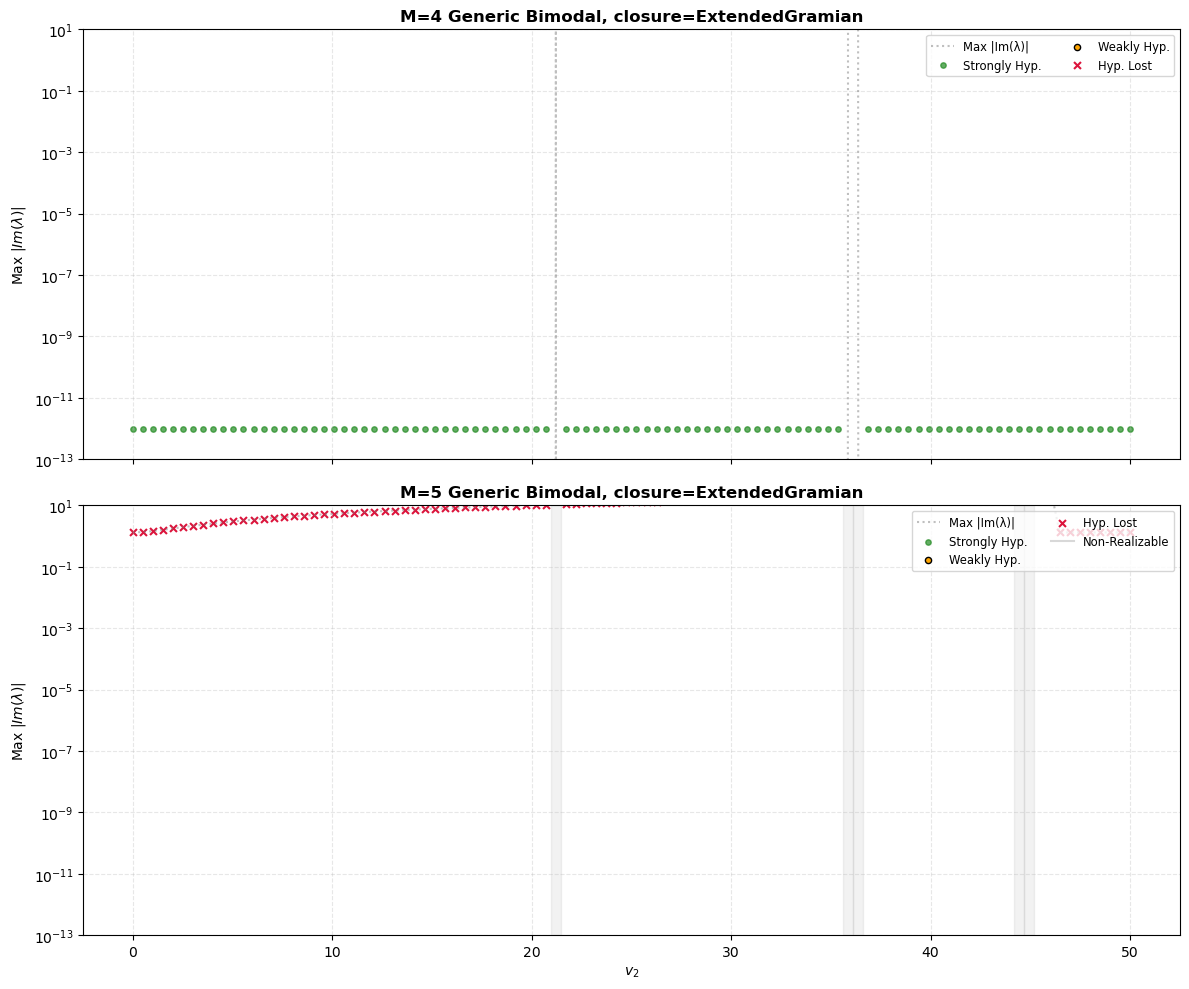

Scanning $x$ (M=5): 100%|██████████| 100/100 [00:02<00:00, 34.88it/s]


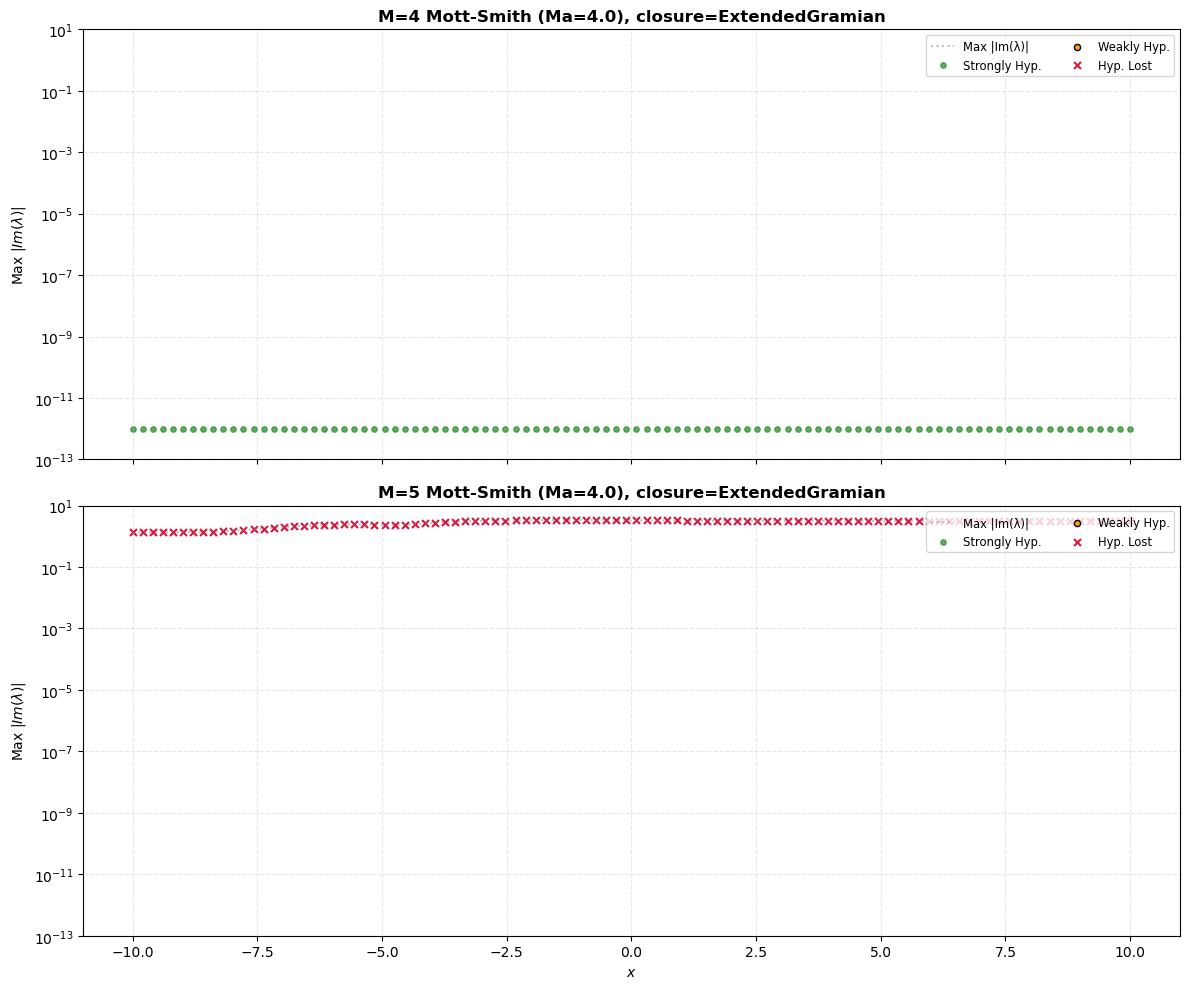

Scanning $\phi$ (M=5): 100%|██████████| 100/100 [00:03<00:00, 31.95it/s]


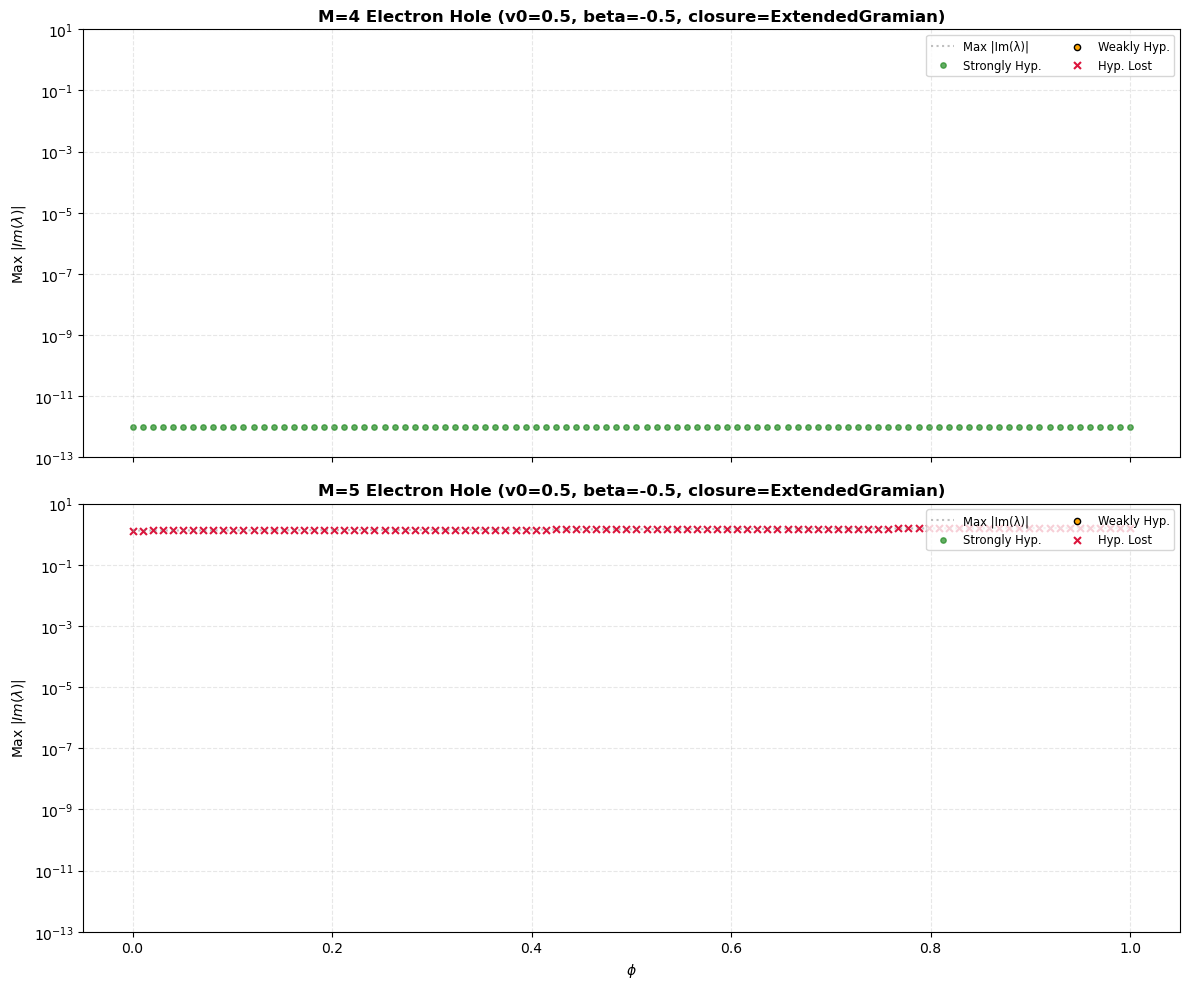

[None, None]

In [ ]:
def investigation_routine(M_List, closure):
    # --- INVESTIGATION 1: Bimodal ---
    rho1, v1, th1, rho2, th2 = 0.4, 0.0, 1.0, 0.6, 1.0
    bimodal_gen = lambda v2, n: get_bimodal_moments(n, rho1, v1, th1, rho2, v2, th2)

    perform_analysis(M_List, np.linspace(0.0, 50.0, 100), "$v_2$", bimodal_gen, f"Generic Bimodal, closure={closure}", closure=closure)

    # --- INVESTIGATION 2: Mott-Smith ---
    Ma, gamma = 4.0, 5/3
    rho_star = (Ma**2 * (gamma + 1)) / (2 + Ma**2 * (gamma - 1))
    v_star = Ma / rho_star
    theta_star = (1 - gamma + 2*gamma*Ma**2) / ((1 + gamma) * rho_star)
    v_scale = np.sqrt(gamma)

    ms_moment_gen = lambda x, n: get_bimodal_moments(
        n, 
        rho1=1/(1+np.exp(x)), v1=Ma*v_scale, th1=1.0, 
        rho2=(1-(1/(1+np.exp(x))))*rho_star, v2=v_star*v_scale, th2=theta_star
    )

    perform_analysis(M_List, np.linspace(-10, 10, 100), "$x$", ms_moment_gen, f"Mott-Smith (Ma={Ma}), closure={closure}", closure=closure)

    # --- INVESTIGATION 3: Electron Hole ---
    v0_eh, beta_eh = 0.5, -0.5
    eh_moment_gen = lambda phi, n: get_eh_moments(n, phi, v0_eh, beta_eh)

    perform_analysis(M_List, np.linspace(0.0, 1.0, 100), "$\\phi$", eh_moment_gen, f"Electron Hole (v0={v0_eh}, beta={beta_eh}, closure={closure})", closure=closure)

M_List = [4, 5]#!, 6, 7]
closures = ["Gramian", "ExtendedGramian"]
[investigation_routine(M_List, closure) for closure in closures]

## NewVersion

Scanning $v_2$ (M=5): 100%|██████████| 100/100 [00:04<00:00, 24.19it/s]


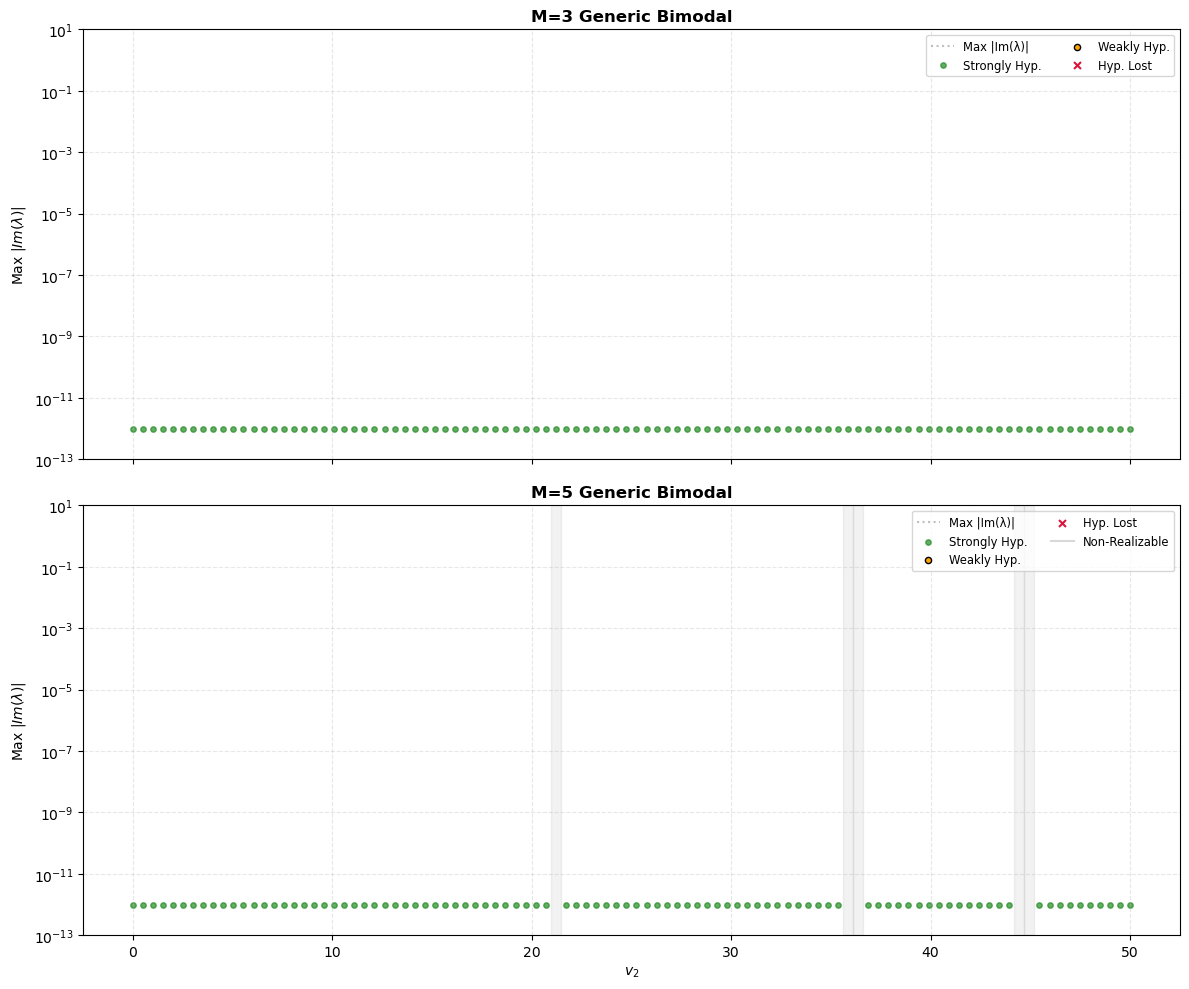

Scanning $x$ (M=5): 100%|██████████| 100/100 [00:02<00:00, 33.59it/s]


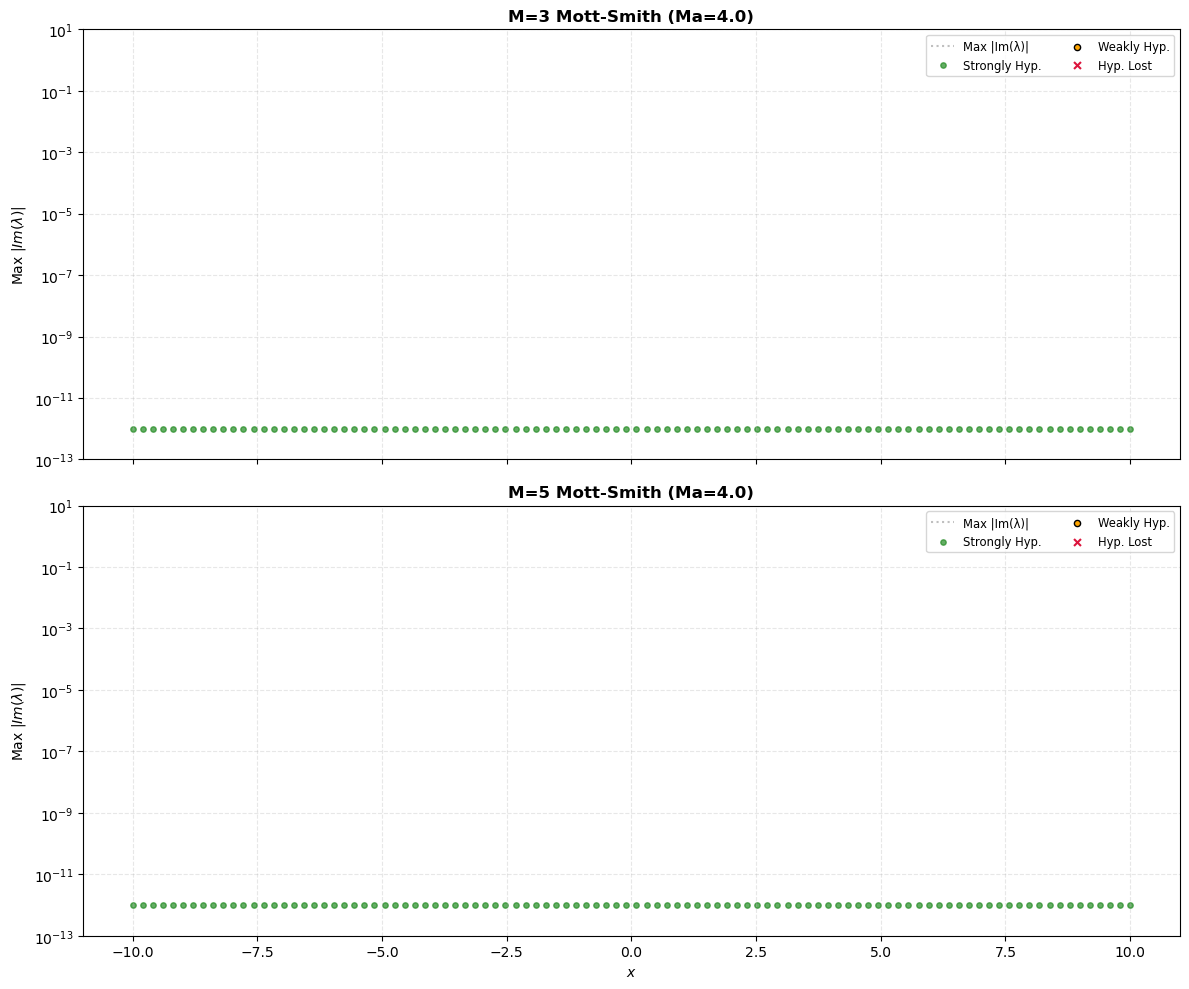

Scanning $\phi$ (M=5): 100%|██████████| 100/100 [00:03<00:00, 31.37it/s]


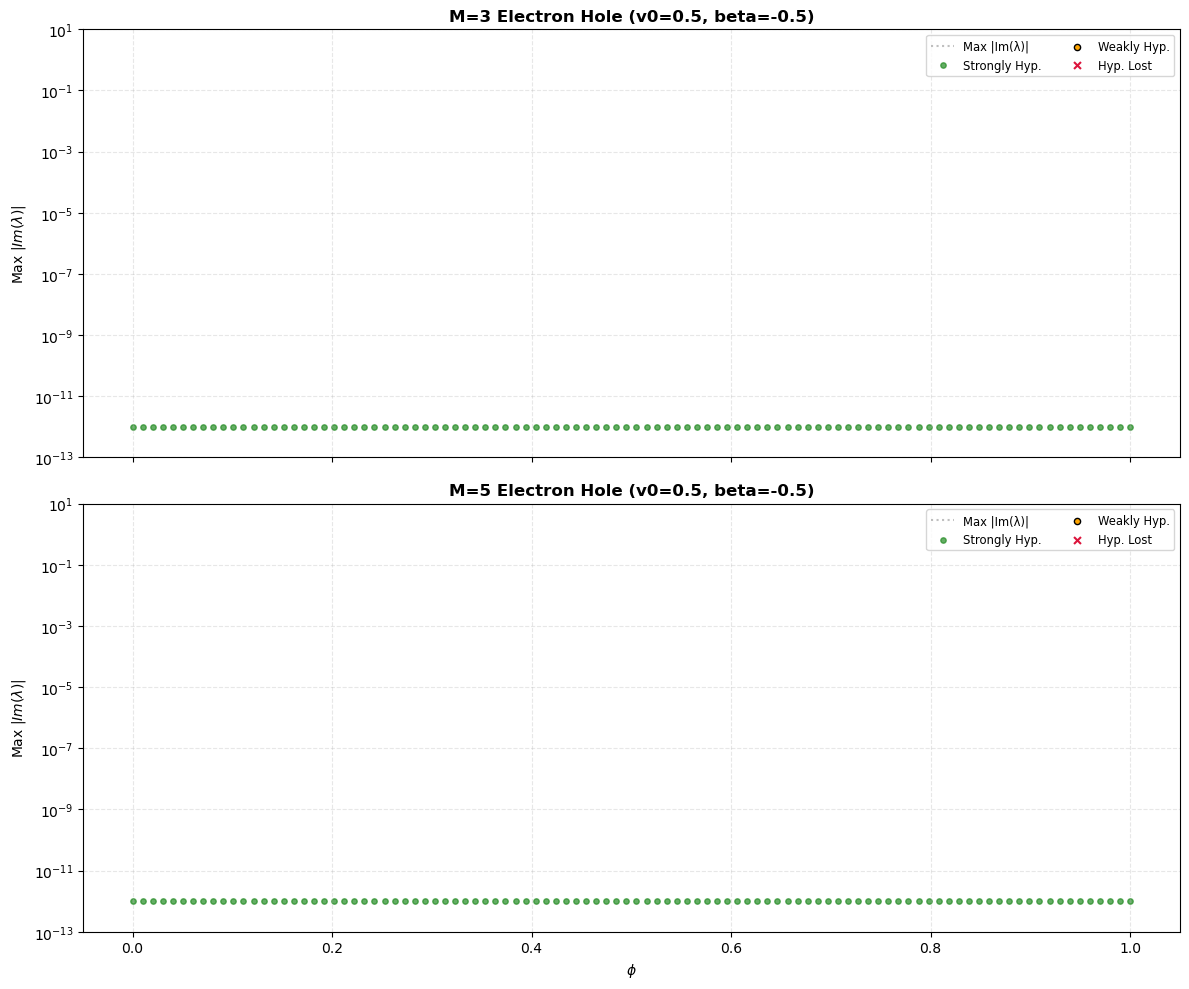

In [ ]:
# --- INVESTIGATION 1: Bimodal ---
rho1, v1, th1, rho2, th2 = 0.4, 0.0, 1.0, 0.6, 1.0
bimodal_gen = lambda v2, n: get_bimodal_moments(n, rho1, v1, th1, rho2, v2, th2)

# perform_analysis([3, 5, 7], np.linspace(0.0, 50.0, 100), "$v_2$", bimodal_gen, "Generic Bimodal")
perform_analysis([3, 5], np.linspace(0.0, 50.0, 100), "$v_2$", bimodal_gen, "Generic Bimodal")

# --- INVESTIGATION 2: Mott-Smith ---
Ma, gamma = 4.0, 5/3
rho_star = (Ma**2 * (gamma + 1)) / (2 + Ma**2 * (gamma - 1))
v_star = Ma / rho_star
theta_star = (1 - gamma + 2*gamma*Ma**2) / ((1 + gamma) * rho_star)
v_scale = np.sqrt(gamma)

ms_moment_gen = lambda x, n: get_bimodal_moments(
    n, 
    rho1=1/(1+np.exp(x)), v1=Ma*v_scale, th1=1.0, 
    rho2=(1-(1/(1+np.exp(x))))*rho_star, v2=v_star*v_scale, th2=theta_star
)

# perform_analysis([3, 5, 7], np.linspace(-10, 10, 100), "$x$", ms_moment_gen, f"Mott-Smith (Ma={Ma})")
perform_analysis([3, 5], np.linspace(-10, 10, 100), "$x$", ms_moment_gen, f"Mott-Smith (Ma={Ma})")

# --- INVESTIGATION 3: Electron Hole ---
v0_eh, beta_eh = 0.5, -0.5
eh_moment_gen = lambda phi, n: get_eh_moments(n, phi, v0_eh, beta_eh)

# perform_analysis([3, 5, 7], np.linspace(0.0, 1.0, 100), "$\\phi$", eh_moment_gen, f"Electron Hole (v0={v0_eh}, beta={beta_eh})")
perform_analysis([3, 5], np.linspace(0.0, 1.0, 100), "$\\phi$", eh_moment_gen, f"Electron Hole (v0={v0_eh}, beta={beta_eh})")

In [ ]:
def run_2d_parameter_map(M, param_x, range_x, param_y, range_y, moment_gen_wrapper, title=""):
    """
    Generates a 2D Heatmap of the maximum imaginary part of eigenvalues.
    Useful for finding the boundary of hyperbolicity and realizability.
    """
    jac_func, n_val = get_jacobian_factory_NewVersion(M)
    X, Y = np.meshgrid(range_x, range_y)
    Z = np.zeros(X.shape)
    status_map = np.zeros(X.shape) # 0: Hyp, 1: Non-Realizable, 2: Elliptic

    print(f"Generating 2D Map for M={M} ({title})...")
    for i in tqdm(range(len(range_y))):
        for j in range(len(range_x)):
            # try:
            # Pass the two variables to the wrapper
            m_list = moment_gen_wrapper(X[i,j], Y[i,j], n_val)
            
            # Realizability check
            G_mat = np.array(sp.Matrix(n_val, n_val, lambda a, b: m_list[a+b]).tolist(), dtype=float)
            if np.linalg.eigvalsh(G_mat).min() < 1e-11:
                Z[i, j] = np.nan 
            else:
                jac_num = jac_func(*m_list)
                evs = np.linalg.eigvals(jac_num)
                max_im = np.max(np.abs(np.imag(evs)))
                Z[i, j] = max_im
            # except:
            #     Z[i, j] = np.nan

    plt.figure(figsize=(10, 8))
    cmap = plt.cm.magma.copy()
    cmap.set_bad(color='lightgray') # Gray for non-realizable regions
    
    # Log scale to see tiny numerical noise vs actual instability
    mesh = plt.pcolormesh(
        X, Y, Z, shading='auto', cmap=cmap, 
        # norm=plt.LogNorm(vmin=1e-10, vmax=1e1)
    )
    
    plt.colorbar(mesh, label='Max |Im(λ)|')
    plt.title(f'Stability Boundary M={M}: {title}')
    plt.xlabel(param_x)
    plt.ylabel(param_y)
    plt.show()

Generating 2D Map for M=3 (Bimodal: Velocity vs Density)...


100%|██████████| 50/50 [00:29<00:00,  1.72it/s]


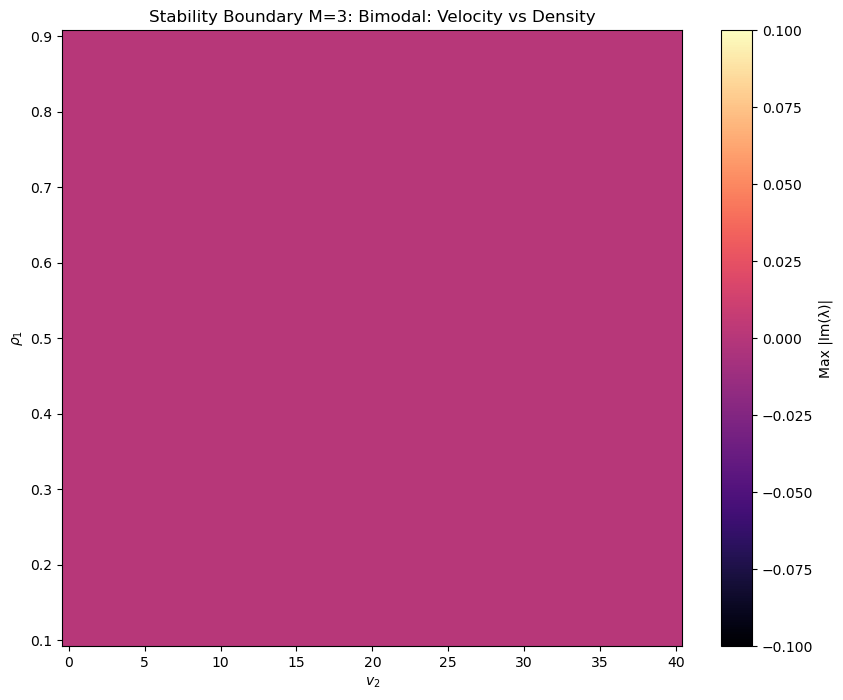

Generating 2D Map for M=5 (Bimodal: Velocity vs Density)...


100%|██████████| 50/50 [00:44<00:00,  1.13it/s]


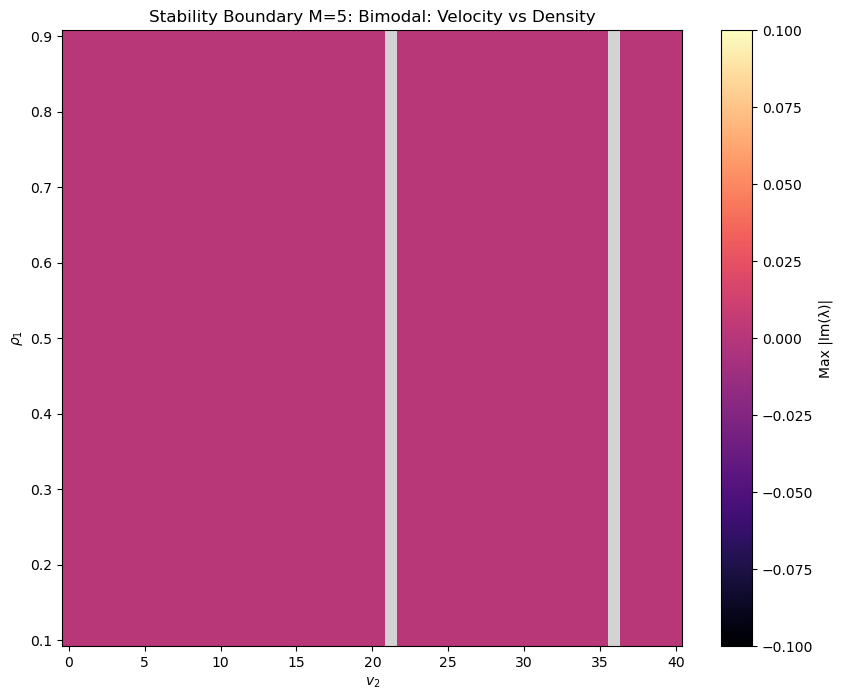

Generating 2D Map for M=3 (Mott-Smith: Shock Position vs Mach Number)...


100%|██████████| 50/50 [00:23<00:00,  2.12it/s]


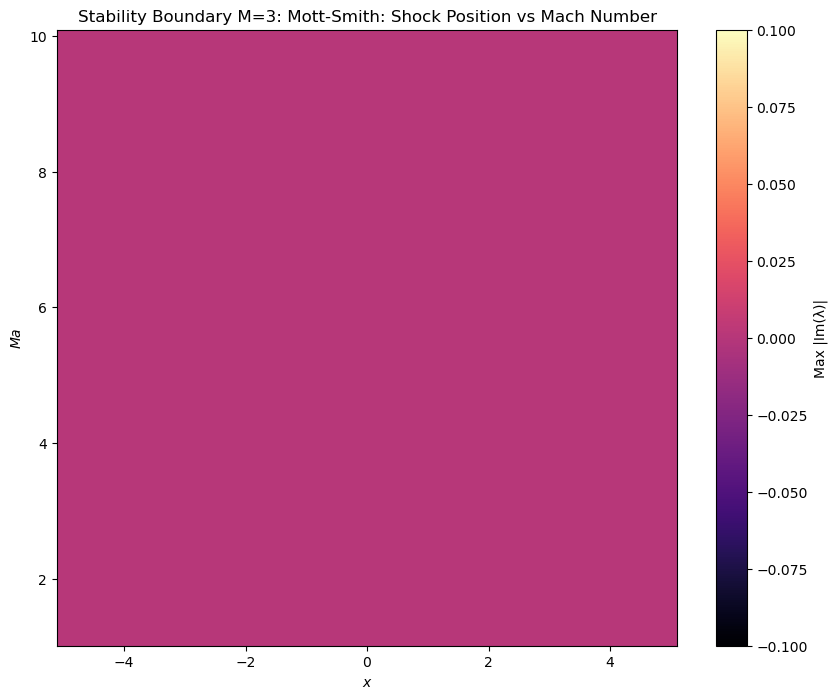

Generating 2D Map for M=5 (Mott-Smith: Shock Position vs Mach Number)...


100%|██████████| 50/50 [00:36<00:00,  1.36it/s]


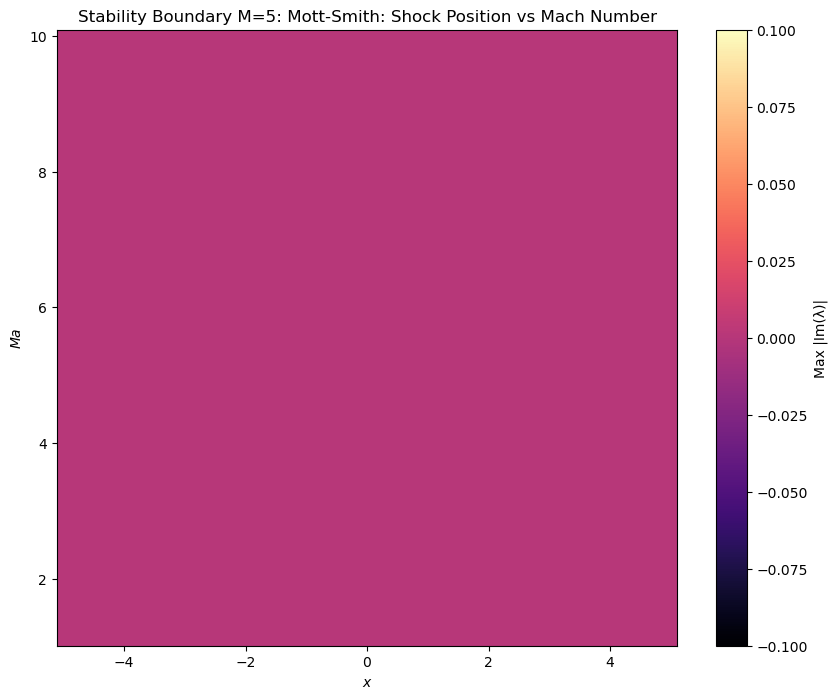

Generating 2D Map for M=3 (Electron Hole: Potential vs Trapping Parameter)...


100%|██████████| 50/50 [00:12<00:00,  4.04it/s]


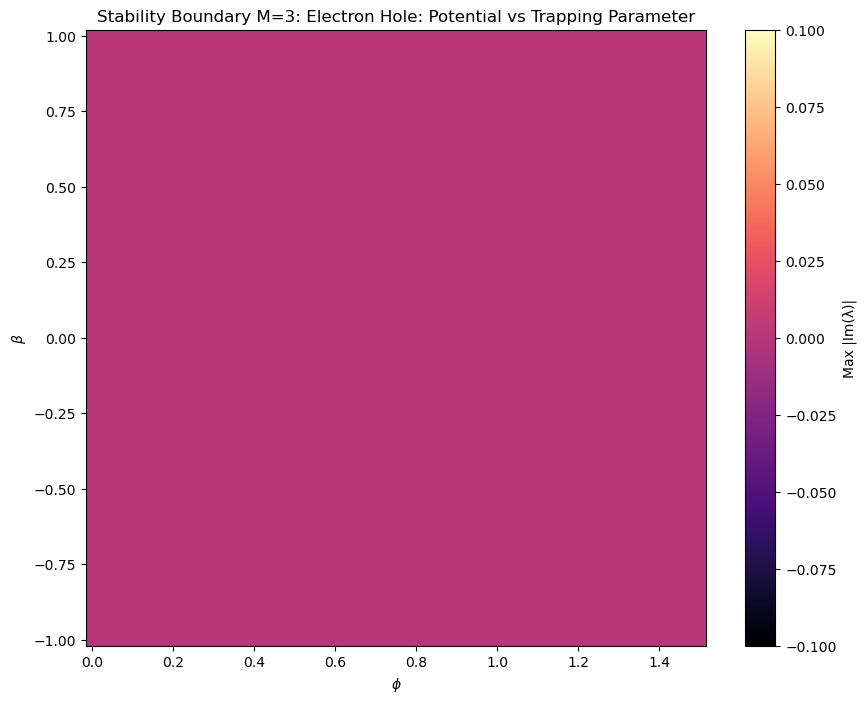

Generating 2D Map for M=5 (Electron Hole: Potential vs Trapping Parameter)...


100%|██████████| 50/50 [00:18<00:00,  2.67it/s]


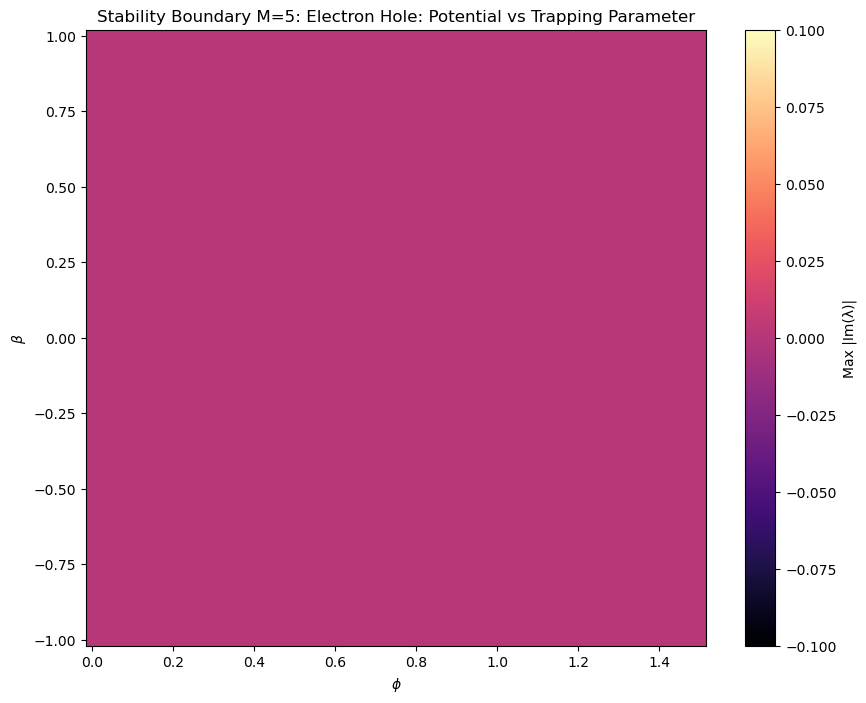

: 

: 

In [ ]:
def main_comprehensive_investigation(M_list=[3, 5]):
    # --- 1. BIMODAL INVESTIGATION ---
    # Analyze the density (rho1) vs velocity (v2)
    bimodal_2d_wrapper = lambda v2, rho1, n: get_bimodal_moments(n, rho1, 0.0, 1.0, 1-rho1, v2, 1.0)
    
    for M in M_list:
        run_2d_parameter_map(
            M, '$v_2$', np.linspace(0, 40, 50), 
            '$\\rho_1$', np.linspace(0.1, 0.9, 50), 
            bimodal_2d_wrapper, "Bimodal: Velocity vs Density"
        )

    # --- 2. MOTT-SMITH SHOCK INVESTIGATION ---
    # Analyze Mach Number (Ma) vs Shock Position (x)
    # This identifies if the closure fails inside high-Mach shock layers.
    def mott_smith_2d_wrapper(x, Ma, n, gamma=5/3):
        rho_star = (Ma**2 * (gamma + 1)) / (2 + Ma**2 * (gamma - 1))
        v_star = Ma / rho_star
        theta_star = (1 - gamma + 2*gamma*Ma**2) / ((1 + gamma) * rho_star)
        v_scale = np.sqrt(gamma)
        z = 1/(1+np.exp(x))
        return get_bimodal_moments(n, z, Ma*v_scale, 1.0, (1-z)*rho_star, v_star*v_scale, theta_star)

    for M in M_list:
        run_2d_parameter_map(
            M, '$x$', np.linspace(-5, 5, 50), 
            '$Ma$', np.linspace(1.1, 10.0, 50), 
            mott_smith_2d_wrapper, "Mott-Smith: Shock Position vs Mach Number"
        )

    # --- 3. ELECTRON HOLE INVESTIGATION ---
    # Analyze Potential (phi) vs Trapping Parameter (beta)
    # This shows how "hollow" the distribution can get before breaking.
    eh_2d_wrapper = lambda phi, beta, n: get_eh_moments(n, phi, v0=0.0, beta=beta)

    for M in M_list:
        run_2d_parameter_map(
            M, '$\\phi$', np.linspace(0.0, 1.5, 50), 
            '$\\beta$', np.linspace(-1.0, 1.0, 50), 
            eh_2d_wrapper, "Electron Hole: Potential vs Trapping Parameter"
        )

# --- EXECUTE ---
main_comprehensive_investigation(M_list=[3, 5])

In [ ]:
def run_2d_parameter_map_closure(M, param_x, range_x, param_y, range_y, moment_gen_wrapper, closure, title=""):
    """
    Generates a 2D Heatmap of the maximum imaginary part of eigenvalues.
    Useful for finding the boundary of hyperbolicity and realizability.
    """
    jac_func, n_val = get_jacobian_factory_GramOdd(M, version=closure)#!get_jacobian_factory_NewVersion(M)
    X, Y = np.meshgrid(range_x, range_y)
    Z = np.zeros(X.shape)
    status_map = np.zeros(X.shape) # 0: Hyp, 1: Non-Realizable, 2: Elliptic

    print(f"Generating 2D Map for M={M} ({title})...")
    for i in tqdm(range(len(range_y))):
        for j in range(len(range_x)):
            # try:
            # Pass the two variables to the wrapper
            m_list = moment_gen_wrapper(X[i,j], Y[i,j], n_val)
            
            # Realizability check
            G_mat = np.array(sp.Matrix(n_val, n_val, lambda a, b: m_list[a+b]).tolist(), dtype=float)
            if np.linalg.eigvalsh(G_mat).min() < 1e-11:
                Z[i, j] = np.nan 
            else:
                jac_num = jac_func(*m_list)
                evs = np.linalg.eigvals(jac_num)
                max_im = np.max(np.abs(np.imag(evs)))
                Z[i, j] = max_im
            # except:
            #     Z[i, j] = np.nan

    plt.figure(figsize=(10, 8))
    cmap = plt.cm.magma.copy()
    cmap.set_bad(color='lightgray') # Gray for non-realizable regions
    
    # Log scale to see tiny numerical noise vs actual instability
    mesh = plt.pcolormesh(
        X, Y, Z, shading='auto', cmap=cmap, 
        # norm=plt.LogNorm(vmin=1e-10, vmax=1e1)
    )
    
    plt.colorbar(mesh, label='Max |Im(λ)|')
    plt.title(f'Stability Boundary M={M}: {title}')
    plt.xlabel(param_x)
    plt.ylabel(param_y)
    plt.show()

Generating 2D Map for M=3 (Bimodal: Velocity vs Density)...


100%|██████████| 50/50 [00:29<00:00,  1.72it/s]


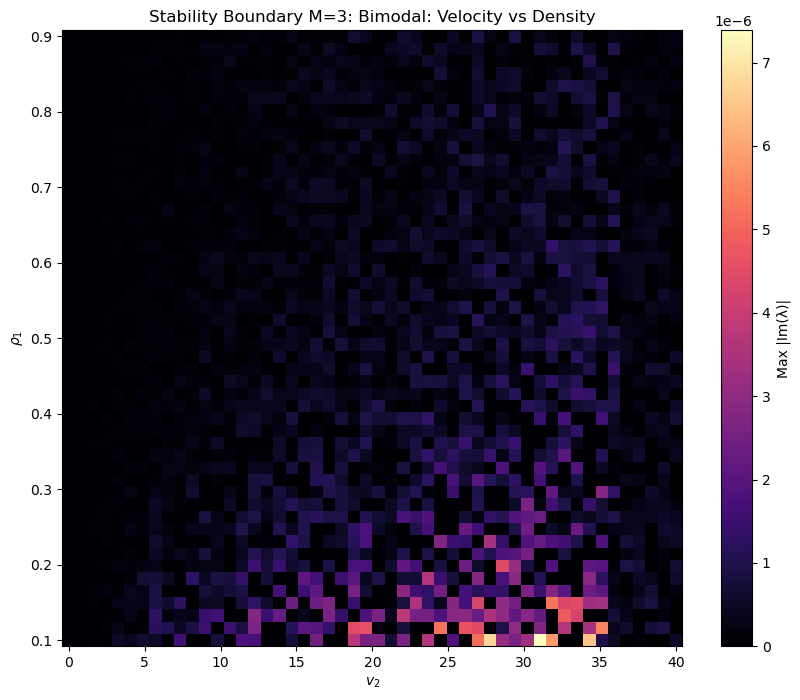

Generating 2D Map for M=3 (Mott-Smith: Shock Position vs Mach Number)...


100%|██████████| 50/50 [00:23<00:00,  2.14it/s]


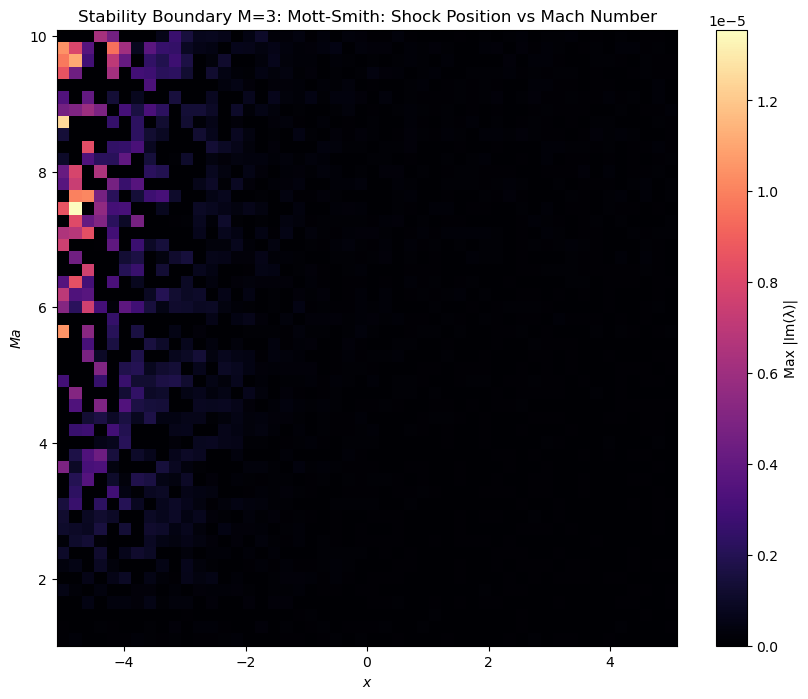

Generating 2D Map for M=3 (Electron Hole: Potential vs Trapping Parameter)...


100%|██████████| 50/50 [00:12<00:00,  4.16it/s]


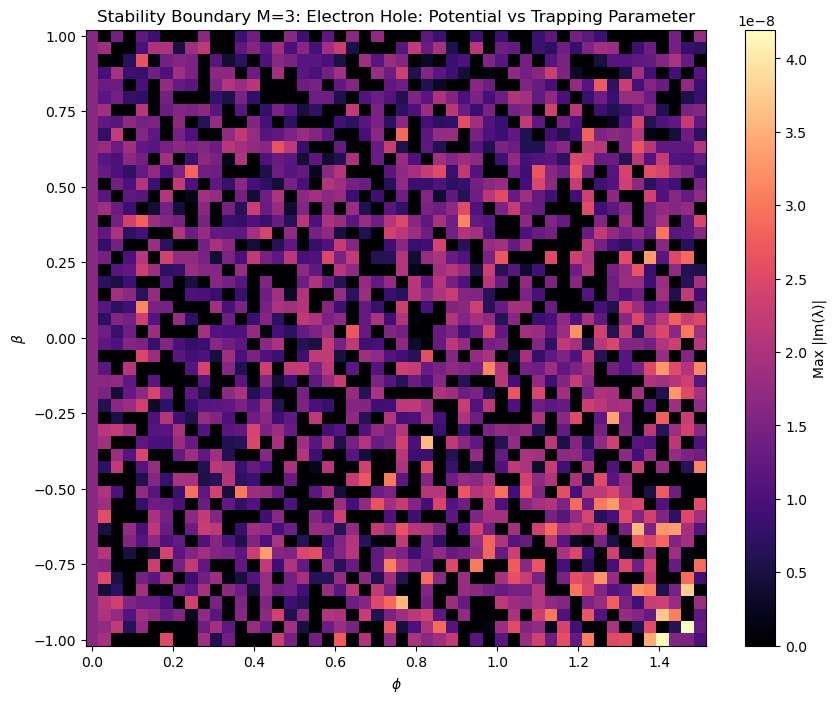

In [ ]:
def main_comprehensive_investigation(M_list, closure):
    # --- 1. BIMODAL INVESTIGATION ---
    # Analyze the density (rho1) vs velocity (v2)
    bimodal_2d_wrapper = lambda v2, rho1, n: get_bimodal_moments(n, rho1, 0.0, 1.0, 1-rho1, v2, 1.0)
    
    for M in M_list:
        run_2d_parameter_map_closure(
            M, '$v_2$', np.linspace(0, 40, 50), 
            '$\\rho_1$', np.linspace(0.1, 0.9, 50), 
            bimodal_2d_wrapper, closure, "Bimodal: Velocity vs Density"
        )

    # --- 2. MOTT-SMITH SHOCK INVESTIGATION ---
    # Analyze Mach Number (Ma) vs Shock Position (x)
    # This identifies if the closure fails inside high-Mach shock layers.
    def mott_smith_2d_wrapper(x, Ma, n, gamma=5/3):
        rho_star = (Ma**2 * (gamma + 1)) / (2 + Ma**2 * (gamma - 1))
        v_star = Ma / rho_star
        theta_star = (1 - gamma + 2*gamma*Ma**2) / ((1 + gamma) * rho_star)
        v_scale = np.sqrt(gamma)
        z = 1/(1+np.exp(x))
        return get_bimodal_moments(n, z, Ma*v_scale, 1.0, (1-z)*rho_star, v_star*v_scale, theta_star)

    for M in M_list:
        run_2d_parameter_map_closure(
            M, '$x$', np.linspace(-5, 5, 50), 
            '$Ma$', np.linspace(1.1, 10.0, 50), 
            mott_smith_2d_wrapper, closure, "Mott-Smith: Shock Position vs Mach Number"
        )

    # --- 3. ELECTRON HOLE INVESTIGATION ---
    # Analyze Potential (phi) vs Trapping Parameter (beta)
    # This shows how "hollow" the distribution can get before breaking.
    eh_2d_wrapper = lambda phi, beta, n: get_eh_moments(n, phi, v0=0.0, beta=beta)

    for M in M_list:
        run_2d_parameter_map_closure(
            M, '$\\phi$', np.linspace(0.0, 1.5, 50), 
            '$\\beta$', np.linspace(-1.0, 1.0, 50), 
            eh_2d_wrapper, closure, "Electron Hole: Potential vs Trapping Parameter"
        )

# --- EXECUTE ---
main_comprehensive_investigation(M_list=[3], closure="Gramian")

Generating 2D Map for M=3 (Bimodal: Velocity vs Density)...


100%|██████████| 50/50 [00:29<00:00,  1.70it/s]


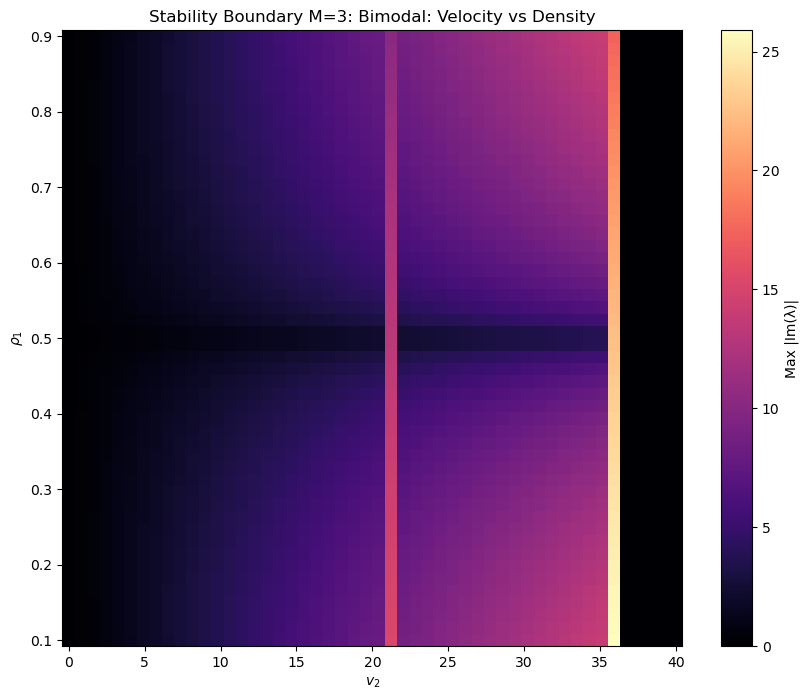

Generating 2D Map for M=3 (Mott-Smith: Shock Position vs Mach Number)...


100%|██████████| 50/50 [00:23<00:00,  2.12it/s]


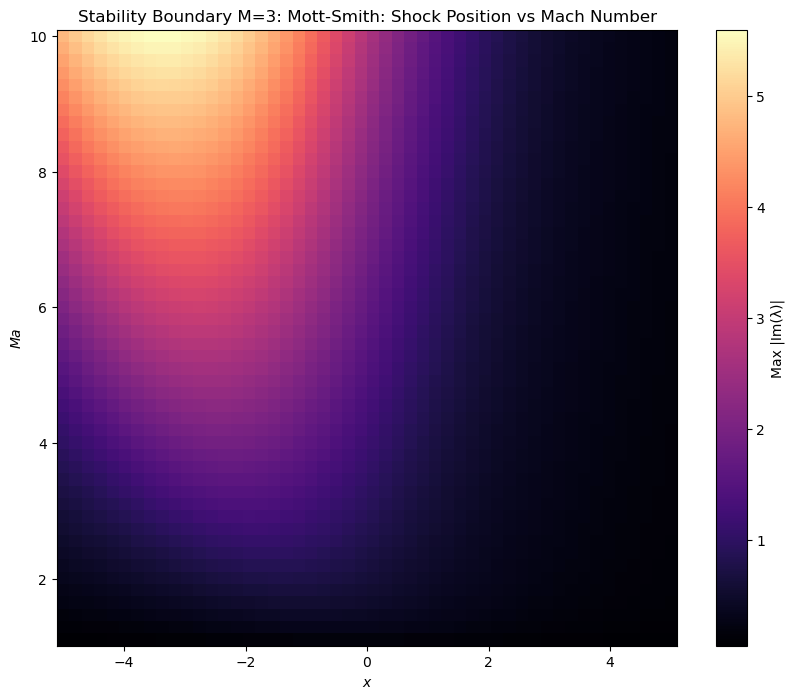

Generating 2D Map for M=3 (Electron Hole: Potential vs Trapping Parameter)...


100%|██████████| 50/50 [00:12<00:00,  4.14it/s]


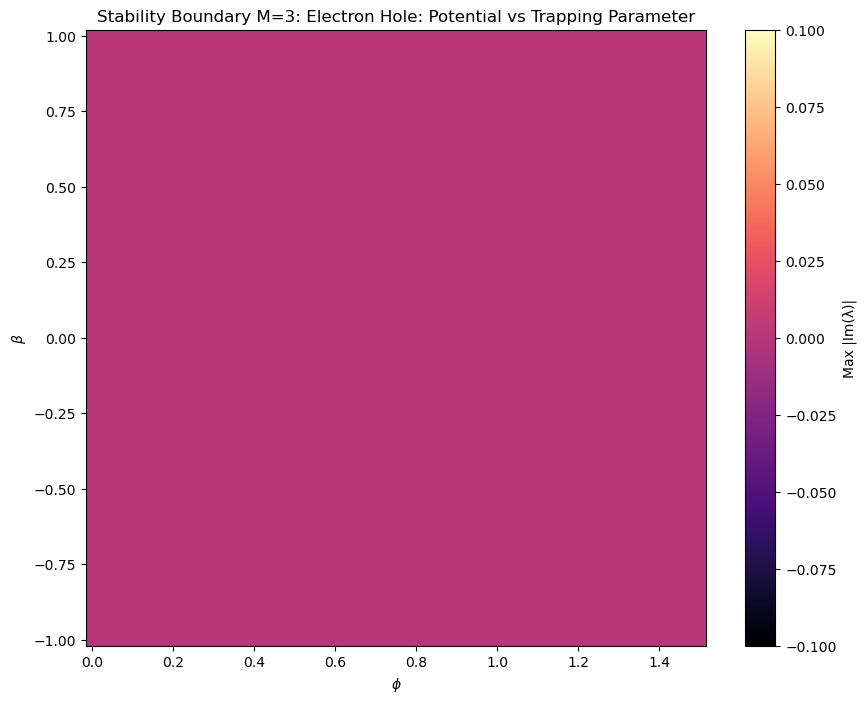

In [ ]:
main_comprehensive_investigation(M_list=[3], closure="ExtendedGramian")

In [ ]:
[main_comprehensive_investigation(M_list=[4], closure=closure) for closure in ["Gramian", "ExtendedGramian"]]

IndexError: list index out of range

In [ ]:
def run_2d_parameter_map_closure_weak_hyperbolic(M, param_x_label, range_x, param_y_label, range_y, 
                                 moment_gen_wrapper, closure_type, title_suffix=""):
    """
    Plots the 'Spectral Gap' (min difference between eigenvalues).
    Near-zero values (dark regions) indicate weak hyperbolicity/eigenvalue collisions.
    """
    # Select the appropriate factory from your notebook
    if M % 2 != 0:
        jac_func, n_val = get_jacobian_factory_GramOdd(M, version=closure_type)
    else:
        jac_func, n_val = get_jacobian_factory_GramEven(M, version=closure_type)
        
    X, Y = np.meshgrid(range_x, range_y)
    Z = np.zeros(X.shape)
    
    print(f"Mapping {closure_type} (M={M}) - Analyzing Eigenvalue Distinctness...")
    
    for i in tqdm(range(len(range_y))):
        for j in range(len(range_x)):
            # Generate moments and check realizability
            m_list = moment_gen_wrapper(X[i,j], Y[i,j], n_val)
            G_mat = np.array(sp.Matrix(n_val, n_val, lambda a, b: m_list[a+b]).tolist(), dtype=float)
            
            # Use the realizability check from your notebook
            if np.linalg.eigvalsh(G_mat).min() < 1e-11:
                Z[i, j] = np.nan 
            else:
                jac_num = jac_func(*m_list)
                evs = np.linalg.eigvals(jac_num)
                
                # Calculate the gap between sorted real parts of eigenvalues
                sorted_evs = np.sort(np.real(evs))
                spectral_gap = np.min(np.diff(sorted_evs))
                
                # We use the gap as our metric. 
                # Small gap = Weak Hyperbolicity (eigenvalue collision)
                Z[i, j] = max(spectral_gap, 1e-12) # Floor for LogNorm

    # Visualization
    plt.figure(figsize=(10, 7))
    cmap = plt.cm.viridis_r.copy() # Reversed Viridis: Purple is 'bad' (gap -> 0)
    cmap.set_bad(color='lightgray') 
    
    # Using mcolors.LogNorm to fix the attribute error
    # This highlights regions where eigenvalues are very close
    norm = mcolors.LogNorm(vmin=1e-5, vmax=Z[~np.isnan(Z)].max())
    
    mesh = plt.pcolormesh(X, Y, Z, shading='auto', cmap=cmap, norm=norm)
    cb = plt.colorbar(mesh)
    cb.set_label('Minimum Eigenvalue Gap $\Delta \lambda$')
    
    plt.title(f"{title_suffix}\n(M={M}, {closure_type} - Spectral Gap)")
    plt.xlabel(param_x_label)
    plt.ylabel(param_y_label)
    plt.gca().set_facecolor('darkgray') 
    plt.show()

Mapping Gramian (M=3) - Analyzing Eigenvalue Distinctness...


100%|██████████| 50/50 [00:31<00:00,  1.58it/s]


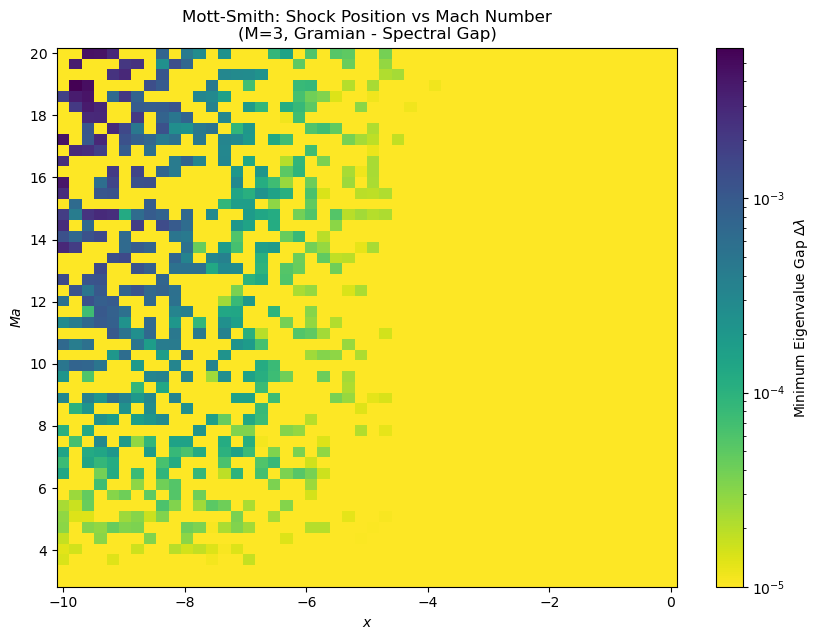

In [ ]:
def main_comprehensive_investigation_weak_hyperbolic(M_list, closure):
    # # --- 1. BIMODAL INVESTIGATION ---
    # # Analyze the density (rho1) vs velocity (v2)
    # bimodal_2d_wrapper = lambda v2, rho1, n: get_bimodal_moments(n, rho1, 0.0, 1.0, 1-rho1, v2, 1.0)
    
    # for M in M_list:
    #     run_2d_parameter_map_closure_weak_hyperbolic(
    #         M, '$v_2$', np.linspace(0, 40, 50), 
    #         '$\\rho_1$', np.linspace(0.1, 0.9, 50), 
    #         bimodal_2d_wrapper, closure, "Bimodal: Velocity vs Density"
    #     )

    # --- 2. MOTT-SMITH SHOCK INVESTIGATION ---
    # Analyze Mach Number (Ma) vs Shock Position (x)
    # This identifies if the closure fails inside high-Mach shock layers.
    def mott_smith_2d_wrapper(x, Ma, n, gamma=5/3):
        rho_star = (Ma**2 * (gamma + 1)) / (2 + Ma**2 * (gamma - 1))
        v_star = Ma / rho_star
        theta_star = (1 - gamma + 2*gamma*Ma**2) / ((1 + gamma) * rho_star)
        v_scale = np.sqrt(gamma)
        z = 1/(1+np.exp(x))
        return get_bimodal_moments(n, z, Ma*v_scale, 1.0, (1-z)*rho_star, v_star*v_scale, theta_star)

    for M in M_list:
        run_2d_parameter_map_closure_weak_hyperbolic(
            M, '$x$', np.linspace(-10, 0, 50), #np.linspace(-5, 5, 50), 
            '$Ma$', np.linspace(3.0, 20.0, 50), #np.linspace(1.1, 10.0, 50), 
            mott_smith_2d_wrapper, closure, "Mott-Smith: Shock Position vs Mach Number"
        )

    # # --- 3. ELECTRON HOLE INVESTIGATION ---
    # # Analyze Potential (phi) vs Trapping Parameter (beta)
    # # This shows how "hollow" the distribution can get before breaking.
    # eh_2d_wrapper = lambda phi, beta, n: get_eh_moments(n, phi, v0=0.0, beta=beta)

    # for M in M_list:
    #     run_2d_parameter_map_closure_weak_hyperbolic(
    #         M, '$\\phi$', np.linspace(0.0, 1.5, 50), 
    #         '$\\beta$', np.linspace(-1.0, 1.0, 50), 
    #         eh_2d_wrapper, closure, "Electron Hole: Potential vs Trapping Parameter"
    #     )


# --- ODD GRAMIAN: ANALYZING EIGENVALUE COLLISIONS ---
main_comprehensive_investigation_weak_hyperbolic(M_list=[3], closure="Gramian")